In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('M1_final.csv')

In [36]:
df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,TAIL_NUM,DEST,DEP_DELAY,CRS_ELAPSED_TIME,DISTANCE,CRS_DEP_M,...,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Condition,sch_dep,sch_arr,TAXI_OUT
0,11,1,5,B6,N828JB,CHS,-1,124,636,324,...,34,58,W,25,38,29.86,Fair / Windy,9,17,14
1,11,1,5,B6,N992JB,LAX,-7,371,2475,340,...,34,58,W,25,38,29.86,Fair / Windy,9,17,15
2,11,1,5,B6,N959JB,FLL,40,181,1069,301,...,34,58,W,25,38,29.86,Fair / Windy,9,17,22
3,11,1,5,B6,N999JQ,MCO,-2,168,944,345,...,34,58,W,25,38,29.86,Fair / Windy,9,17,12
4,11,1,5,DL,N880DN,ATL,-4,139,760,360,...,32,58,W,24,35,29.91,Fair / Windy,9,17,13


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28820 entries, 0 to 28819
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28820 non-null  int64  
 1   DAY_OF_MONTH       28820 non-null  int64  
 2   DAY_OF_WEEK        28820 non-null  int64  
 3   OP_UNIQUE_CARRIER  28820 non-null  object 
 4   TAIL_NUM           28820 non-null  object 
 5   DEST               28820 non-null  object 
 6   DEP_DELAY          28820 non-null  int64  
 7   CRS_ELAPSED_TIME   28820 non-null  int64  
 8   DISTANCE           28820 non-null  int64  
 9   CRS_DEP_M          28820 non-null  int64  
 10  DEP_TIME_M         28820 non-null  int64  
 11  CRS_ARR_M          28820 non-null  int64  
 12  Temperature        28820 non-null  int64  
 13  Dew Point          28820 non-null  object 
 14  Humidity           28820 non-null  int64  
 15  Wind               28818 non-null  object 
 16  Wind Speed         288

In [38]:
df.nunique()

MONTH                   3
DAY_OF_MONTH           31
DAY_OF_WEEK             7
OP_UNIQUE_CARRIER       9
TAIL_NUM             2092
DEST                   65
DEP_DELAY             342
CRS_ELAPSED_TIME      327
DISTANCE               64
CRS_DEP_M             606
DEP_TIME_M           1240
CRS_ARR_M             970
Temperature            51
Dew Point              64
Humidity               78
Wind                   18
Wind Speed             30
Wind Gust              28
Pressure              149
Condition              25
sch_dep                56
sch_arr                47
TAXI_OUT               37
dtype: int64

In [39]:
import pandas as pd

df = pd.read_csv("M1_final.csv")

df = df.rename(columns={
    "MONTH": "mes",
    "DAY_OF_MONTH": "dia_del_mes",
    "DAY_OF_WEEK": "dia_de_la_semana",
    "OP_UNIQUE_CARRIER": "aerolinea",
    "TAIL_NUM": "matricula_avion",
    "DEST": "destino",
    "DEP_DELAY": "retraso_salida",
    "CRS_ELAPSED_TIME": "duracion_programada",
    "DISTANCE": "distancia",
    "CRS_DEP_M": "hora_salida_programada",
    "DEP_TIME_M": "hora_salida_real",
    "CRS_ARR_M": "hora_llegada_programada",
    "Temperature": "temperatura",
    "Dew Point": "punto_de_rocio",
    "Humidity": "humedad",
    "Wind": "direccion_viento",
    "Wind Speed": "velocidad_viento",
    "Wind Gust": "rafaga_viento",
    "Pressure": "presion",
    "Condition": "condicion_climatica",
    "sch_dep": "salidas_programadas",
    "sch_arr": "llegadas_programadas",
    "TAXI_OUT": "tiempo_rodaje"
})

df.to_csv("M1_final_traducido.csv", index=False)

In [48]:


aerolineas = {
    "B6": "JetBlue",
    "DL": "Delta",
    "9E": "Endeavor Air",
    "AA": "American Airlines",
    "AS": "Alaska Airlines",
    "MQ": "Envoy Air",
    "YX": "Republic Airways",
    "OO": "SkyWest",
    "HA": "Hawaiian Airlines"
}

df["aerolinea"] = df["aerolinea"].replace(aerolineas)

df.to_csv("M1_final_traducido.csv", index=False)

In [49]:
#Quiero separar en categóricas y numéricas, para poder hacer un análisis más profundo de los datos. 
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)


Categorical columns: Index(['aerolinea', 'matricula_avion', 'destino', 'punto_de_rocio',
       'direccion_viento', 'condicion_climatica'],
      dtype='object')
Numerical columns: Index(['mes', 'dia_del_mes', 'dia_de_la_semana', 'retraso_salida',
       'duracion_programada', 'distancia', 'hora_salida_programada',
       'hora_salida_real', 'hora_llegada_programada', 'temperatura', 'humedad',
       'velocidad_viento', 'rafaga_viento', 'presion', 'salidas_programadas',
       'llegadas_programadas', 'tiempo_rodaje'],
      dtype='object')


Análisis Outliers

In [50]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percentage = (len(outliers) / len(df)) * 100
    print(f"Column: {col}, Outliers: {len(outliers)}", f"({outlier_percentage:.2f}%)")

Column: mes, Outliers: 0 (0.00%)
Column: dia_del_mes, Outliers: 0 (0.00%)
Column: dia_de_la_semana, Outliers: 0 (0.00%)
Column: retraso_salida, Outliers: 4027 (13.97%)
Column: duracion_programada, Outliers: 0 (0.00%)
Column: distancia, Outliers: 102 (0.35%)
Column: hora_salida_programada, Outliers: 0 (0.00%)
Column: hora_salida_real, Outliers: 0 (0.00%)
Column: hora_llegada_programada, Outliers: 0 (0.00%)
Column: temperatura, Outliers: 178 (0.62%)
Column: humedad, Outliers: 5 (0.02%)
Column: velocidad_viento, Outliers: 324 (1.12%)
Column: rafaga_viento, Outliers: 5313 (18.44%)
Column: presion, Outliers: 32 (0.11%)
Column: salidas_programadas, Outliers: 665 (2.31%)
Column: llegadas_programadas, Outliers: 0 (0.00%)
Column: tiempo_rodaje, Outliers: 512 (1.78%)


Las columnas con los outliers más significativos son rafaga_viento y restraso salida

In [51]:
#Análisis univariado de las variables categóricas
resumen= pd.DataFrame({
    'Media':df[numerical_columns].mean(), 
    'Mediana':df[numerical_columns].median(),
    'Moda':df[numerical_columns].mode().iloc[0],
    'Desviación Estándar':df[numerical_columns].std(),
    'IQR':df[numerical_columns].quantile(0.75) - df[numerical_columns].quantile(0.25),
    'Skewness':df[numerical_columns].skew()}).round(3)
print('Resumen estadístico de las variables numéricas:')
print(resumen)

Resumen estadístico de las variables numéricas:
                            Media  Mediana     Moda  Desviación Estándar  \
mes                         7.894    11.00     1.00                4.992   
dia_del_mes                16.021    16.00    20.00                8.750   
dia_de_la_semana            4.009     4.00     5.00                1.985   
retraso_salida              6.375    -3.00    -5.00               38.735   
duracion_programada       225.288   188.00   390.00              119.482   
distancia                1267.746  1029.00  2475.00              889.343   
hora_salida_programada    831.004   856.00   485.00              299.399   
hora_salida_real          828.935   854.00   479.00              305.864   
hora_llegada_programada   910.874   918.00   630.00              345.412   
temperatura                41.490    42.00    40.00                8.044   
humedad                    57.733    59.00    10.00               23.469   
velocidad_viento           12.368    12.

Rafaga_viento: tiene un IQR de 0 (significa que el percentil 75 y el percentil 25 tienen el mismo valor)con un skewness de 1.790, lo cual nos indica que los datos no varían pero que puede haber una cola de valores altos. 

retraso_salida: tiene un IQR bajo pero un skewness de 10.686. Indica lo mismo que el caso anterior, los datos están acotados en un rango chico y hay valores muy alejados que no se reflejan en el IQR, pero si disparan el skewness.

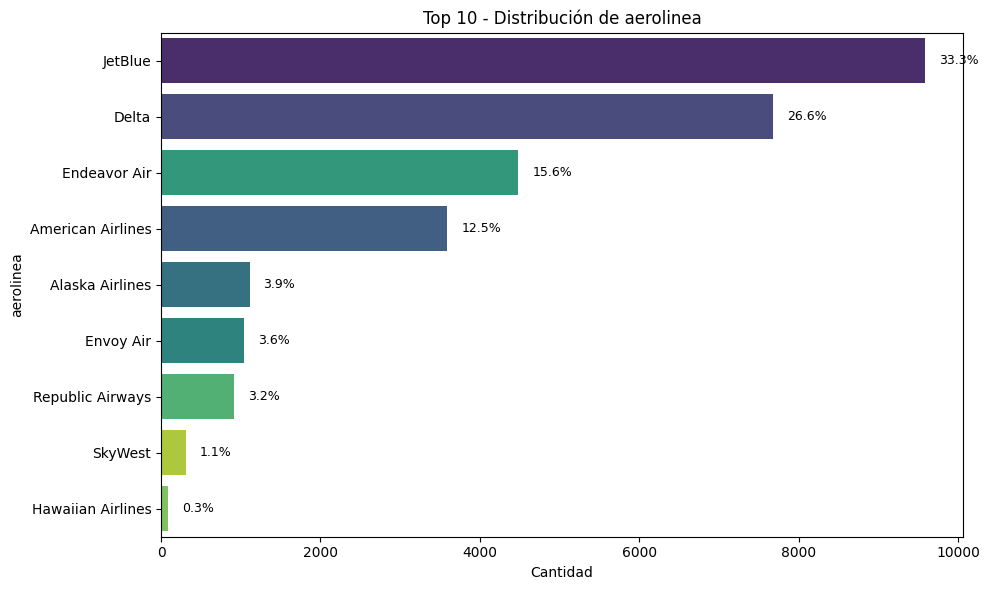

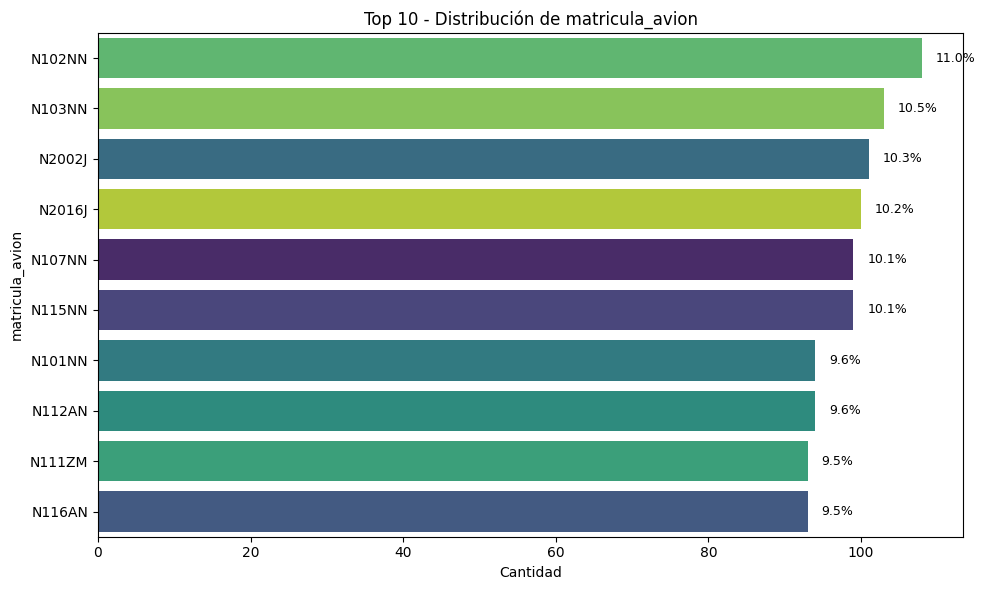

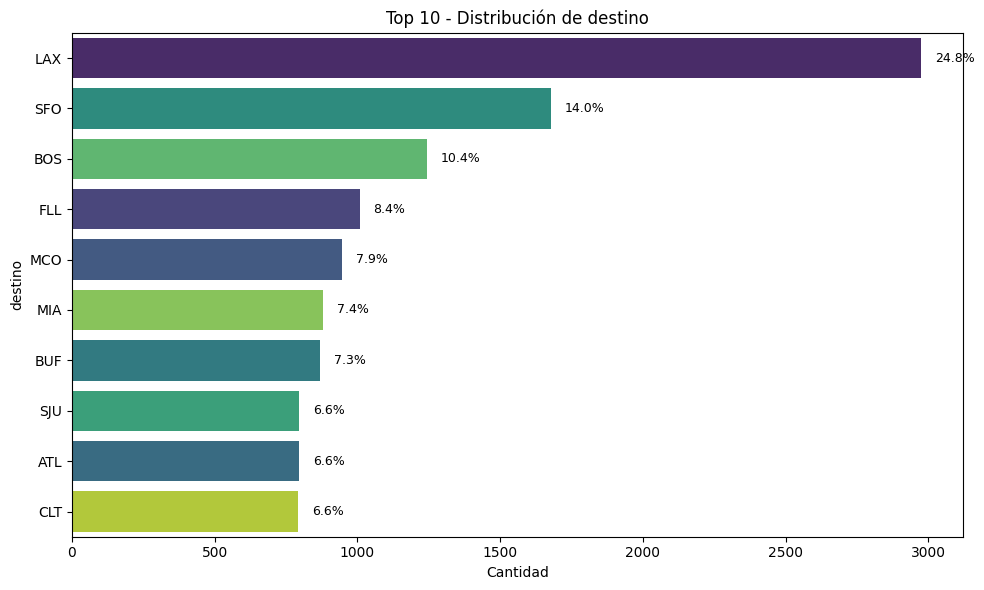

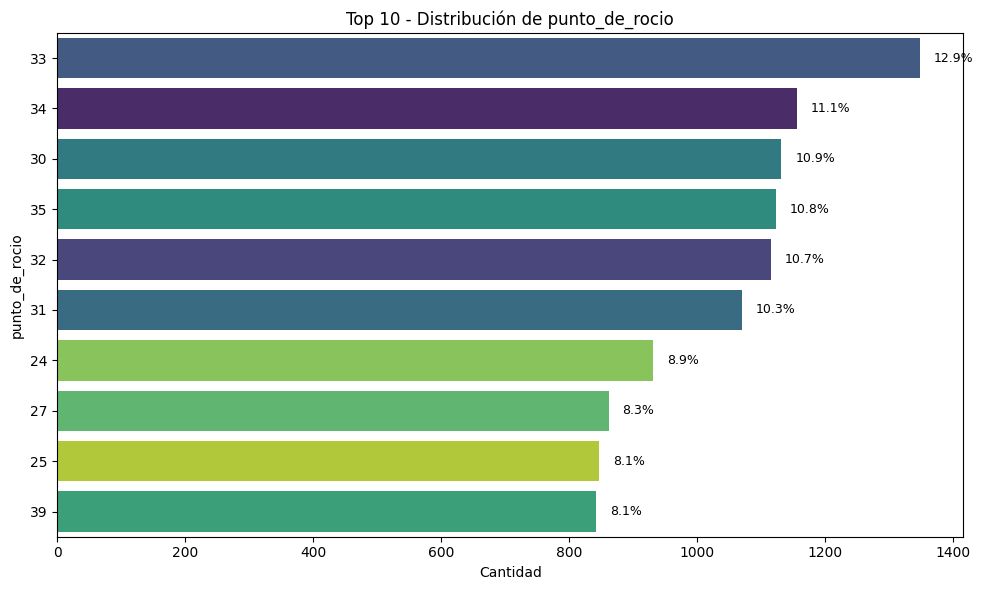

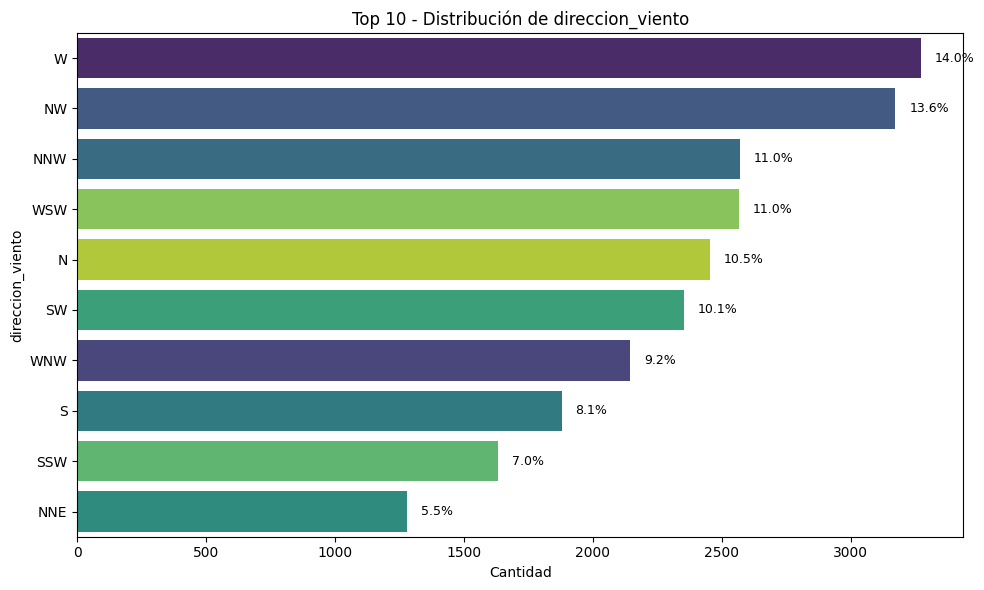

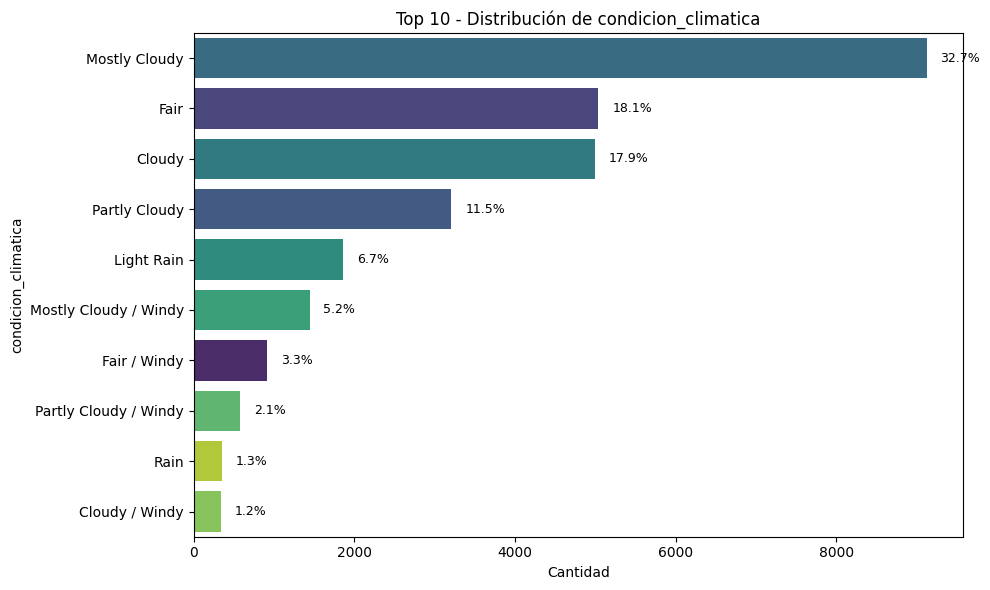

In [54]:
for col in categorical_columns:
    top10 = df[col].value_counts().nlargest(10).index
    df_top10 = df[df[col].isin(top10)]

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df_top10, y=col, hue=col, palette='viridis', legend=False, order=top10)
    plt.title(f'Top 10 - Distribución de {col}')
    plt.xlabel('Cantidad')
    plt.ylabel(col)

    total = len(df_top10)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.annotate(percentage, (x, y), ha='left', va='center', fontsize=9, color='black', xytext=(10, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

Condición climática

La mayoría de los vuelos se registraron bajo condiciones de cielo mayormente nublado o despejado, mientras que las condiciones de con viento y lluevia representan una proción minoritaria, lo que nos da a entender que el clima adverso no es lo más usual.

mostly_cloudy: 32.7%
fair: 18.1%
cloudy: 17.9%

Por otro lado, existe una fuerte concnetración en pocos aeropuertos como LAX (Los Ángeles) con un 25%, seguido por SFO (San Francisco) con un 14% y luego BOS (Boston) con un 10.4%. Lo cual nos puede indicar que la mayoría de los vuelos son más para el Oeste de EEUU.

Por último, podemos ver que las aerolíneas con mayor cantidad de vuelos son JetBlue con un 33.3% y Delta con un 26.6% representan en conjunto un 60% de los vuelos.